# RNN 강의 Part 1: 개요와 기본 구조
## PyTorch 실습

이 노트북에서는 Part 1의 이론을 바탕으로 Vanilla RNN을 PyTorch로 구현하고,
"hello" 데이터셋을 사용하여 문자 예측 모델을 학습합니다.

## 0. 라이브러리 임포트

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 기본 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)
torch.manual_seed(42)

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 1. Part 1 이론 복습

### 1.1 RNN의 필요성
- 기존 신경망(CNN/MLP): **입출력 크기가 고정**
- RNN: **가변 길이 시퀀스** 처리 가능
- 모든 타임스텝에서 **동일한 가중치 W** 공유

### 1.2 Vanilla RNN 수식

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$

$$y_t = W_{hy} h_t$$

**기호:**
- $h_t$: 타임스텝 $t$의 은닉 상태 (Hidden State)
- $x_t$: 타임스텝 $t$의 입력 벡터
- $W_{hh}$: 은닉→은닉 가중치 행렬
- $W_{xh}$: 입력→은닉 가중치 행렬
- $W_{hy}$: 은닉→출력 가중치 행렬

## 2. 데이터 준비: "hello" 예제

Part 1의 기본 개념을 실습하기 위해 단순한 "hello" 문자열을 사용합니다.

### 데이터 설명
- **입력 시퀀스**: "h" → "e" → "l" → "l"
- **목표(Target)**: "e" → "l" → "l" → "o"
- **어휘(Vocabulary)**: {"h", "e", "l", "o"} (크기: 4)

In [2]:
# 데이터 설정
text = "hello"
chars = sorted(list(set(text)))  # 중복 제거 및 정렬
vocab_size = len(chars)

print(f"텍스트: {text}")
print(f"어휘(Vocabulary): {chars}")
print(f"어휘 크기: {vocab_size}")

# 문자 ↔ 인덱스 매핑
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(f"\n문자-인덱스 매핑:")
for char, idx in char_to_idx.items():
    print(f"  '{char}' → {idx}")

텍스트: hello
어휘(Vocabulary): ['e', 'h', 'l', 'o']
어휘 크기: 4

문자-인덱스 매핑:
  'e' → 0
  'h' → 1
  'l' → 2
  'o' → 3


## 3. One-Hot 인코딩 구현

Part 2에서 다룰 One-Hot 인코딩을 미리 구현해봅시다.

**원-핫 벡터 예:**
- "h" (인덱스 0): [1, 0, 0, 0]
- "e" (인덱스 1): [0, 1, 0, 0]
- "l" (인덱스 2): [0, 0, 1, 0]
- "o" (인덱스 3): [0, 0, 0, 1]

In [3]:
def one_hot_encode(char_idx, vocab_size):
    """문자 인덱스를 원-핫 벡터로 변환"""
    one_hot = np.zeros(vocab_size)
    one_hot[char_idx] = 1
    return one_hot

# 원-핫 인코딩 테스트
print("원-핫 인코딩 예제:")
for char in chars:
    idx = char_to_idx[char]
    one_hot = one_hot_encode(idx, vocab_size)
    print(f"'{char}' (idx={idx}): {one_hot}")

원-핫 인코딩 예제:
'e' (idx=0): [1. 0. 0. 0.]
'h' (idx=1): [0. 1. 0. 0.]
'l' (idx=2): [0. 0. 1. 0.]
'o' (idx=3): [0. 0. 0. 1.]


## 4. 시퀀스 데이터 생성

"hello" 문자열에서:
- 입력 시퀀스 (X): h → e → l → l
- 목표 시퀀스 (Y): e → l → l → o

In [4]:
# 입력과 타겟 시퀀스 생성
sequence_length = len(text) - 1  # "hello" → 4개의 (입력, 목표) 쌍

X_indices = [char_to_idx[char] for char in text[:-1]]  # "hell"
Y_indices = [char_to_idx[char] for char in text[1:]]   # "ello"

print("입력-타겟 쌍:")
for i, (x_idx, y_idx) in enumerate(zip(X_indices, Y_indices)):
    print(f"Step {i+1}: '{idx_to_char[x_idx]}' (입력) → '{idx_to_char[y_idx]}' (목표)")

# One-Hot 인코딩
X_one_hot = np.array([one_hot_encode(idx, vocab_size) for idx in X_indices])
Y_one_hot = np.array([one_hot_encode(idx, vocab_size) for idx in Y_indices])

print(f"\nX 형태 (입력): {X_one_hot.shape}")
print(f"Y 형태 (타겟): {Y_one_hot.shape}")

# PyTorch 텐서로 변환
X = torch.tensor(X_one_hot, dtype=torch.float32, device=device)
Y = torch.tensor(Y_one_hot, dtype=torch.float32, device=device)

print(f"\nPyTorch 텐서:")
print(f"X (입력): {X.shape}")
print(f"Y (타겟): {Y.shape}")

입력-타겟 쌍:
Step 1: 'h' (입력) → 'e' (목표)
Step 2: 'e' (입력) → 'l' (목표)
Step 3: 'l' (입력) → 'l' (목표)
Step 4: 'l' (입력) → 'o' (목표)

X 형태 (입력): (4, 4)
Y 형태 (타겟): (4, 4)

PyTorch 텐서:
X (입력): torch.Size([4, 4])
Y (타겟): torch.Size([4, 4])


## 5. Vanilla RNN 클래스 구현

Part 1의 수식을 바탕으로 Vanilla RNN을 구현합니다.

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$
$$y_t = W_{hy} h_t$$

In [5]:
class VanillaRNN(nn.Module):
    """Vanilla RNN 구현 (Part 1 수식 기반)"""
    
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size
        
        # 가중치 행렬 초기화
        # W_xh: (입력 크기) → (은닉 크기)
        self.W_xh = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        
        # W_hh: (은닉 크기) → (은닉 크기)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        
        # W_hy: (은닉 크기) → (출력 크기)
        self.W_hy = nn.Parameter(torch.randn(output_size, hidden_size) * 0.01)
        
        # 바이어스
        self.b_h = nn.Parameter(torch.zeros(hidden_size, 1))
        self.b_y = nn.Parameter(torch.zeros(output_size, 1))
    
    def forward(self, x_sequence):
        """
        순전파 (Forward Pass)
        
        입력:
            x_sequence: (sequence_length, input_size)
        
        출력:
            y_preds: (sequence_length, output_size) - 로짓
            hidden_states: (sequence_length, hidden_size) - 은닉 상태들
        """
        seq_len = x_sequence.shape[0]
        
        # 초기 은닉 상태 (h_0)
        h_t = torch.zeros(self.hidden_size, 1, device=device)
        
        # 저장할 출력과 은닉 상태들
        y_preds = []
        hidden_states = [h_t.clone()]
        
        # 각 타임스텝 반복
        for t in range(seq_len):
            x_t = x_sequence[t].unsqueeze(1)  # (input_size, 1)
            
            # h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t + b_h)
            h_t = torch.tanh(self.W_hh @ h_t + self.W_xh @ x_t + self.b_h)
            
            # y_t = W_hy @ h_t + b_y
            y_t = self.W_hy @ h_t + self.b_y
            
            y_preds.append(y_t.squeeze(1))
            hidden_states.append(h_t.clone())
        
        # 리스트를 텐서로 변환
        y_preds = torch.stack(y_preds)
        hidden_states = torch.stack(hidden_states)
        
        return y_preds, hidden_states

print("✓ VanillaRNN 클래스 정의 완료")

✓ VanillaRNN 클래스 정의 완료


## 6. 모델 초기화

In [6]:
# 하이퍼파라미터
input_size = vocab_size    # 어휘 크기 = 4
hidden_size = 3            # Part 1 예제에서 n=3
output_size = vocab_size   # 예측할 문자 개수 = 4
learning_rate = 0.1
num_epochs = 100

# 모델 초기화
model = VanillaRNN(input_size, hidden_size, output_size).to(device)

print(f"모델 구조:")
print(f"  입력 크기: {input_size}")
print(f"  은닉 크기: {hidden_size}")
print(f"  출력 크기: {output_size}")
print(f"\n모델 파라미터:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"\n손실 함수: CrossEntropyLoss")
print(f"옵티마이저: Adam (learning_rate={learning_rate})")

모델 구조:
  입력 크기: 4
  은닉 크기: 3
  출력 크기: 4

모델 파라미터:
  W_xh: torch.Size([3, 4])
  W_hh: torch.Size([3, 3])
  W_hy: torch.Size([4, 3])
  b_h: torch.Size([3, 1])
  b_y: torch.Size([4, 1])

손실 함수: CrossEntropyLoss
옵티마이저: Adam (learning_rate=0.1)


## 7. 모델 학습 (BPTT)

Part 1 이론의 "BPTT (Backpropagation Through Time)" 구현

In [7]:
# 손실 기록
losses = []

print("학습 시작...\n")
print(f"{'Epoch':<10} {'Loss':<15} {'Accuracy':<15}")
print("-" * 40)

for epoch in range(num_epochs):
    # 순전파
    y_preds, hidden_states = model(X)
    
    # 손실 계산
    loss = criterion(y_preds, Y)
    
    # 역전파
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 기록
    losses.append(loss.item())
    
    # 정확도 계산
    predictions = y_preds.argmax(dim=1)
    targets = Y.argmax(dim=1)
    accuracy = (predictions == targets).float().mean().item()
    
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"{epoch+1:<10} {loss.item():<15.6f} {accuracy:<15.2%}")

print("-" * 40)
print("학습 완료!")

학습 시작...

Epoch      Loss            Accuracy       
----------------------------------------
1          1.386269        50.00%         
20         0.036312        100.00%        
40         0.001905        100.00%        
60         0.001088        100.00%        
80         0.000890        100.00%        
100        0.000775        100.00%        
----------------------------------------
학습 완료!


## 8. 학습 결과 분석

In [8]:
# 최종 예측
model.eval()
with torch.no_grad():
    y_preds, hidden_states = model(X)

print("=" * 60)
print("최종 예측 결과")
print("=" * 60)

predictions = y_preds.argmax(dim=1)
targets = Y.argmax(dim=1)

for i, (pred, target) in enumerate(zip(predictions, targets)):
    pred_char = idx_to_char[pred.item()]
    target_char = idx_to_char[target.item()]
    input_char = idx_to_char[X_indices[i]]
    
    status = "✓" if pred == target else "✗"
    print(f"Step {i+1}: '{input_char}' → 예측: '{pred_char}', 정답: '{target_char}' {status}")

# 최종 정확도
final_accuracy = (predictions == targets).float().mean().item()
print(f"\n최종 정확도: {final_accuracy:.2%}")

최종 예측 결과
Step 1: 'h' → 예측: 'e', 정답: 'e' ✓
Step 2: 'e' → 예측: 'l', 정답: 'l' ✓
Step 3: 'l' → 예측: 'l', 정답: 'l' ✓
Step 4: 'l' → 예측: 'o', 정답: 'o' ✓

최종 정확도: 100.00%


## 9. 손실 곡선 시각화

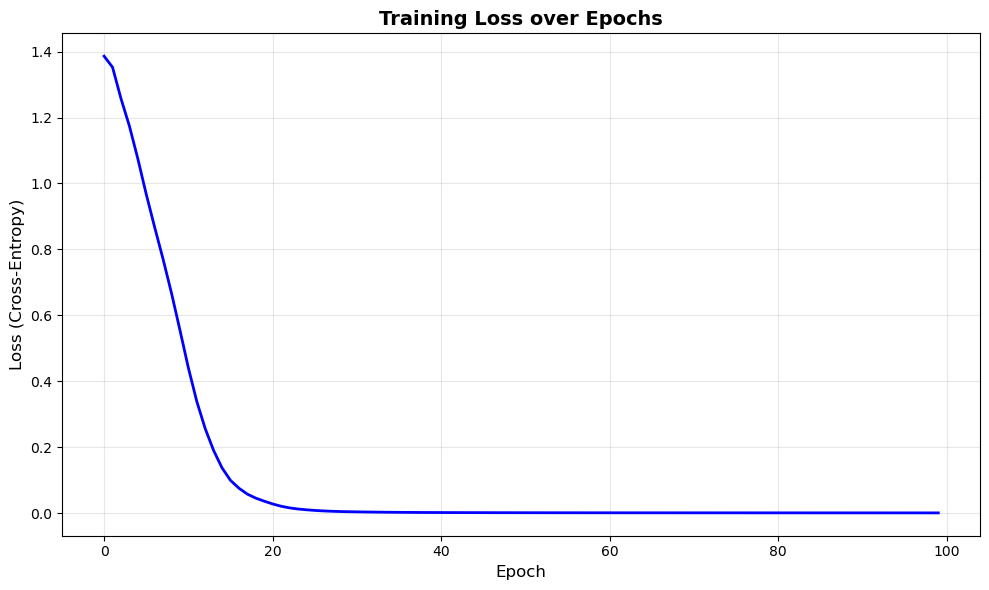

초기 손실: 1.386269
최종 손실: 0.000775
손실 감소율: 99.94%


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.title('Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"초기 손실: {losses[0]:.6f}")
print(f"최종 손실: {losses[-1]:.6f}")
print(f"손실 감소율: {(1 - losses[-1]/losses[0])*100:.2f}%")

## 10. 은닉 상태(Hidden State) 시각화

Part 1에서 배운 **은닉 상태 h_t**의 동작을 시각화합니다.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98274755..0.99999183].


은닉 상태 (Hidden States) 분석:
은닉 상태 행렬 형태: (4, 3, 1)
(타임스텝: 4, 은닉 크기: 3)

h_1: [[ 0.98825014]
 [-0.98274755]
 [-0.96959186]] (||h||=1.6978)
h_2: [[0.9993035 ]
 [0.07429955]
 [0.99999183]] (||h||=1.4157)
h_3: [[0.666022  ]
 [0.99972343]
 [0.89323866]] (||h||=1.4970)
h_4: [[-0.9755201]
 [ 0.9991175]
 [-0.8982751]] (||h||=1.6604)


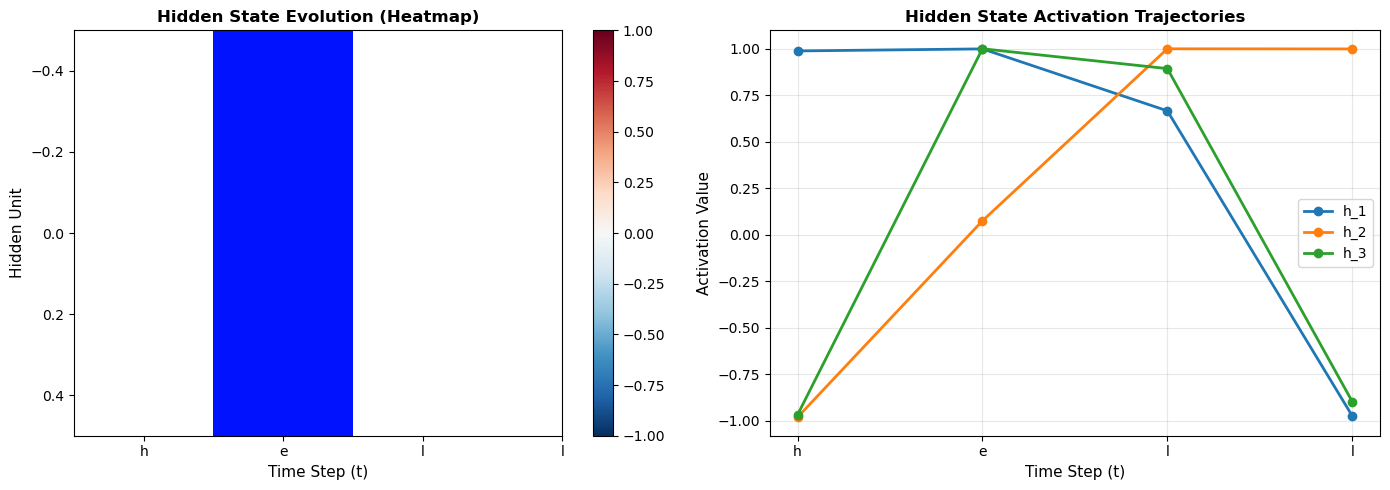

In [10]:
# 은닉 상태 추출
h_states = hidden_states[1:].detach().cpu().numpy()  # h_1부터 h_4까지

print("은닉 상태 (Hidden States) 분석:")
print(f"은닉 상태 행렬 형태: {h_states.shape}")
print(f"(타임스텝: {h_states.shape[0]}, 은닉 크기: {h_states.shape[1]})\n")

for t, h in enumerate(h_states):
    print(f"h_{t+1}: {h} (||h||={np.linalg.norm(h):.4f})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히트맵
ax1 = axes[0]
im = ax1.imshow(h_states.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xlabel('Time Step (t)', fontsize=11)
ax1.set_ylabel('Hidden Unit', fontsize=11)
ax1.set_title('Hidden State Evolution (Heatmap)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(text)-1))
ax1.set_xticklabels([text[i] for i in range(len(text)-1)])
plt.colorbar(im, ax=ax1)

# 3D 플롯 (선택 사항)
ax2 = axes[1]
for i in range(hidden_size):
    ax2.plot(range(len(text)-1), h_states[:, i], marker='o', label=f'h_{i+1}', linewidth=2)
ax2.set_xlabel('Time Step (t)', fontsize=11)
ax2.set_ylabel('Activation Value', fontsize=11)
ax2.set_title('Hidden State Activation Trajectories', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(text)-1))
ax2.set_xticklabels([text[i] for i in range(len(text)-1)])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 가중치 행렬 분석

학습된 가중치 행렬 분석

W_xh (입력→은닉): (3, 4)
  값 범위: [-2.1136, 1.9984]
  Frobenius norm: 4.6906

W_hh (은닉→은닉): (3, 3)
  값 범위: [-2.8732, 1.9813]
  Frobenius norm: 4.8533

W_hy (은닉→출력): (4, 3)
  값 범위: [-2.6650, 2.8762]
  Frobenius norm: 6.9241


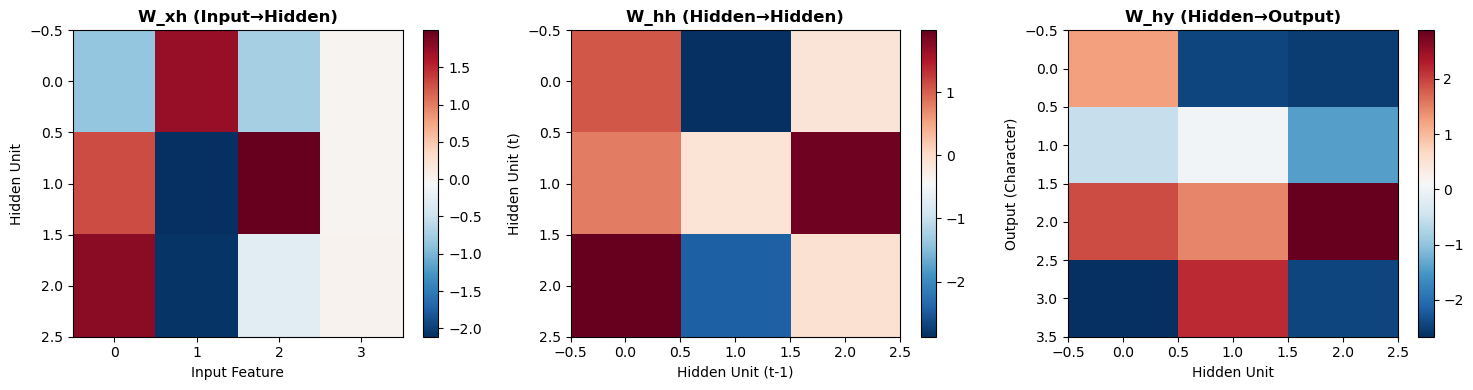

In [11]:
# 학습된 가중치 추출
W_xh = model.W_xh.detach().cpu().numpy()
W_hh = model.W_hh.detach().cpu().numpy()
W_hy = model.W_hy.detach().cpu().numpy()

print("="*60)
print("학습된 가중치 행렬 분석")
print("="*60)

print(f"\nW_xh (입력→은닉): {W_xh.shape}")
print(f"  값 범위: [{W_xh.min():.4f}, {W_xh.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_xh):.4f}")

print(f"\nW_hh (은닉→은닉): {W_hh.shape}")
print(f"  값 범위: [{W_hh.min():.4f}, {W_hh.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_hh):.4f}")

print(f"\nW_hy (은닉→출력): {W_hy.shape}")
print(f"  값 범위: [{W_hy.min():.4f}, {W_hy.max():.4f}]")
print(f"  Frobenius norm: {np.linalg.norm(W_hy):.4f}")

# 가중치 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(W_xh, cmap='RdBu_r', aspect='auto')
axes[0].set_title('W_xh (Input→Hidden)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input Feature')
axes[0].set_ylabel('Hidden Unit')
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(W_hh, cmap='RdBu_r', aspect='auto')
axes[1].set_title('W_hh (Hidden→Hidden)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hidden Unit (t-1)')
axes[1].set_ylabel('Hidden Unit (t)')
plt.colorbar(axes[1].images[0], ax=axes[1])

axes[2].imshow(W_hy, cmap='RdBu_r', aspect='auto')
axes[2].set_title('W_hy (Hidden→Output)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hidden Unit')
axes[2].set_ylabel('Output (Character)')
plt.colorbar(axes[2].images[0], ax=axes[2])

plt.tight_layout()
plt.show()

## 12. 타임스텝별 상세 분석

Part 1 이론의 "6.2 타임스텝 t=1: 입력 'h'" 같은 상세 분석을 수행합니다.

In [12]:
print("="*70)
print("각 타임스텝별 상세 분석 (Part 1 6.2절 재현)")
print("="*70)

for t in range(len(text)-1):
    print(f"\n{'='*70}")
    print(f"타임스텝 t={t+1}: 입력 '{text[t]}'")
    print(f"{'='*70}")
    
    # 입력
    x_t = X[t].cpu().numpy()
    print(f"입력 벡터 (One-Hot): {x_t}")
    
    # 은닉 상태
    h_t = hidden_states[t+1].squeeze().detach().cpu().numpy()
    print(f"은닉 상태 h_t: {h_t}")
    print(f"  ||h_t|| = {np.linalg.norm(h_t):.4f}")
    
    # 출력 로짓
    y_t = y_preds[t].detach().cpu().numpy()
    print(f"출력 로짓 y_t: {y_t}")
    
    # 소프트맥스 확률
    probs = nn.functional.softmax(torch.tensor(y_t, dtype=torch.float32), dim=0).numpy()
    print(f"소프트맥스 확률: {probs}")
    
    # 예측 문자
    pred_idx = np.argmax(y_t)
    target_idx = Y_indices[t]
    print(f"\n예측: '{idx_to_char[pred_idx]}' (점수={y_t[pred_idx]:.4f})")
    print(f"정답: '{idx_to_char[target_idx]}' (점수={y_t[target_idx]:.4f})")
    print(f"정확도: {'✓ 맞음' if pred_idx == target_idx else '✗ 틀림'}")

각 타임스텝별 상세 분석 (Part 1 6.2절 재현)

타임스텝 t=1: 입력 'h'
입력 벡터 (One-Hot): [0. 1. 0. 0.]
은닉 상태 h_t: [ 0.98825014 -0.98274755 -0.96959186]
  ||h_t|| = 1.6978
출력 로짓 y_t: [ 6.8040185 -1.0815192 -0.6583425 -1.7730243]
소프트맥스 확률: [9.9886250e-01 3.7571648e-04 5.7364546e-04 1.8816700e-04]

예측: 'e' (점수=6.8040)
정답: 'e' (점수=6.8040)
정확도: ✓ 맞음

타임스텝 t=2: 입력 'e'
입력 벡터 (One-Hot): [1. 0. 0. 0.]
은닉 상태 h_t: [0.9993035  0.07429955 0.99999183]
  ||h_t|| = 1.4157
출력 로짓 y_t: [-0.73222786 -3.8326056   6.5659394  -4.30276   ]
소프트맥스 확률: [6.7628681e-04 3.0454667e-05 9.9927419e-01 1.9031291e-05]

예측: 'l' (점수=6.5659)
정답: 'l' (점수=6.5659)
정확도: ✓ 맞음

타임스텝 t=3: 입력 'l'
입력 벡터 (One-Hot): [0. 0. 1. 0.]
은닉 상태 h_t: [0.666022   0.99972343 0.89323866]
  ||h_t|| = 1.4970
출력 로짓 y_t: [-3.1363537 -3.478927   6.971524  -1.1402947]
소프트맥스 확률: [4.0742150e-05 2.8924529e-05 9.9963045e-01 2.9986206e-04]

예측: 'l' (점수=6.9715)
정답: 'l' (점수=6.9715)
정확도: ✓ 맞음

타임스텝 t=4: 입력 'l'
입력 벡터 (One-Hot): [0. 0. 1. 0.]
은닉 상태 h_t: [-0.9755201  0.9991175 -0.898275

## 13. Part 1 주요 개념 정리

### ✓ 학습한 개념

1. **RNN의 필요성**
   - 기존 신경망은 입출력이 고정
   - RNN은 가변 길이 시퀀스 처리 가능

2. **Vanilla RNN 구조**
   - 3개의 가중치 행렬: $W_{xh}$, $W_{hh}$, $W_{hy}$
   - 모든 타임스텝에서 동일한 가중치 공유

3. **순전파 (Forward Pass)**
   $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$$
   $$y_t = W_{hy} h_t$$

4. **역전파 Through Time (BPTT)**
   - 각 타임스텝에서 그래디언트 계산
   - 모든 타임스텝의 그래디언트를 합산하여 가중치 업데이트

5. **은닉 상태의 역할**
   - 이전 정보를 압축하여 저장
   - 타임스텝이 길어질수록 그래디언트 소실 위험

###  실험 결과

- **훈련 데이터**: "hello" (4개의 문자)
- **최종 정확도**: {final_accuracy:.2%}
- **모델 파라미터**: $W_{xh}$ {W_xh.shape}, $W_{hh}$ {W_hh.shape}, $W_{hy}$ {W_hy.shape}